# Aggregated neural networks under random and targeted damage

This notebook studies how an aggregated spatial neural network survives damage.

The core idea is simple:

1. Start from an adjacency matrix `A_agg` representing the aggregated network.
2. Generate a comparable **random geometric graph** using `networkx.random_geometric_graph`.
3. Damage both networks using several protocols.
4. Measure how the graph structure degrades.
5. Run an Izhikevich spiking simulation after damage.
6. Compare structural damage with functional collapse in the raster/activity.

The notebook is designed so that the **structural part only needs the adjacency matrix**. That is important: degree, hubs, betweenness, communities, bridge nodes, giant component, efficiency, clustering and modularity can all be computed from `A`.

The functional simulation needs extra assumptions: excitatory/inhibitory identity, synaptic weights, noise and Izhikevich parameters. Those are generated reproducibly from the adjacency matrix size and a random seed.

## Main scientific question

> Does spatial aggregation create local robustness but global fragility?

More concretely:

- Random damage should often be tolerated at low damage because local aggregates are redundant.
- Hub damage should disrupt strongly connected local regions.
- Betweenness or bridge-node damage should disrupt communication between aggregates and may collapse activity earlier.
- A random geometric null model lets us ask whether this behaviour is specific to aggregation or simply due to spatial wiring.

In [1]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from collections import defaultdict

# Make figures readable by default
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# 1. Global configuration

For a first test, use modest values. Once the code works, increase `REPEATS`, `SIM_TIME`, and the number of damage fractions.

For `N≈2000`, exact betweenness centrality can be slow. Therefore the notebook uses approximate betweenness by default when the network is large.

In [84]:
# ============================================================
# Configuration
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

# Damage fractions. Example: 0.2 means removing 20% of nodes.
DAMAGE_FRACTIONS = np.round(np.linspace(0.0, 0.8, 9), 2)

# Repeats for stochastic damage and stochastic neural simulation.
# Increase to 20-50 for final plots.
REPEATS = 5

# Simulation parameters. Start small, then increase.
SIM_TIME = 1000       # ms
BIN_SIZE = 20         # ms for population activity statistics

# Izhikevich / synaptic parameters
EXCITATORY_FRACTION = 0.8
MAX_EXC_WEIGHT = 2.9
MAX_INH_WEIGHT = 0.5
NOISE_EXC = 3.0
NOISE_INH = 2.0

# Structural metric approximation
EFFICIENCY_SAMPLE_SIZE = 200
BETWEENNESS_SAMPLE_SIZE = 200

# Whether to run the expensive spiking simulation in the full batch experiment.
# You can set this False to first debug only structural metrics.
RUN_SIMULATION = True

# 2. Utility functions for adjacency matrices

The whole analysis is built around `A`, an adjacency matrix.

Assumptions:

- `A[i, j] = 1` means there is a connection from neuron `j` to neuron `i` in the simulation convention used later, because the input current is computed as `S[:, fired]`.
- For structural graph metrics, we usually treat the network as undirected by symmetrising it.
- Self-connections are removed.

In [3]:
def clean_adjacency(A):
    """
    Convert any adjacency-like object into a clean 0/1 numpy array.
    Removes self-connections.
    """
    A = np.asarray(A).copy()
    A = (A > 0).astype(int)
    np.fill_diagonal(A, 0)
    return A


def symmetrise_adjacency(A):
    """
    Return an undirected binary adjacency matrix.
    If either A[i,j] or A[j,i] exists, the undirected edge exists.
    """
    A = clean_adjacency(A)
    return ((A + A.T) > 0).astype(int)


def adjacency_to_graph(A, undirected=True):
    """
    Convert adjacency matrix to a NetworkX graph.
    """
    A = clean_adjacency(A)
    if undirected:
        A = symmetrise_adjacency(A)
        return nx.from_numpy_array(A)
    else:
        return nx.from_numpy_array(A, create_using=nx.DiGraph)


def graph_to_adjacency(G, nodelist=None):
    """
    Convert NetworkX graph to a clean numpy adjacency matrix.
    """
    if nodelist is None:
        nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist, dtype=int)
    return clean_adjacency(A)


def basic_network_summary(A, name="network"):
    """
    Print basic structural information about a network.
    """
    G = adjacency_to_graph(A, undirected=True)
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()])
    print(f"{name}")
    print("-" * len(name))
    print(f"nodes: {n}")
    print(f"edges: {m}")
    print(f"density: {nx.density(G):.5f}")
    print(f"mean degree: {degrees.mean():.3f}")
    print(f"max degree: {degrees.max() if n > 0 else np.nan}")
    if n > 0:
        comps = list(nx.connected_components(G))
        print(f"components: {len(comps)}")
        print(f"giant component fraction: {len(max(comps, key=len)) / n:.3f}")
    print()

# 3. Load your aggregated network or generate a test one

This cell first checks whether a variable called `A_agg` already exists.

Recommended workflow:

1. Run your original aggregation notebook/cells.
2. Create `A_agg = A.copy()` from your aggregated network.
3. Run this damage notebook.

If `A_agg` does not exist, the cell generates a synthetic aggregated network using Gaussian clusters, similar to your current notebook. This makes the notebook self-contained and testable.

In [29]:
def generate_mixed_positions(
    N,
    L=2.5,
    frac_agg=0.95,
    n_centers=3,
    base_sigma=0.1,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20,
    seed=42,
):
    """
    Generate 2D neuron positions in a square domain.

    A fraction of neurons is placed around Gaussian aggregation centers.
    The rest is placed uniformly at random.
    """
    rng = np.random.default_rng(seed)

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    centers = rng.uniform(low=-L / 2, high=L / 2, size=(n_centers, 2))

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)
    elif sigma_mode == "random":
        sigmas = rng.uniform(sigma_min, sigma_max, size=n_centers)
    else:
        raise ValueError("sigma_mode must be 'same' or 'random'")

    labels = rng.integers(0, n_centers, size=N_agg)
    agg_positions = np.zeros((N_agg, 2))

    for k in range(n_centers):
        idx = np.where(labels == k)[0]
        agg_positions[idx] = centers[k] + sigmas[k] * rng.normal(size=(len(idx), 2))

    rand_positions = rng.uniform(low=-L / 2, high=L / 2, size=(N_rand, 2))
    positions = np.vstack([agg_positions, rand_positions])

    # Keep positions inside the domain by clipping.
    positions = np.clip(positions, -L / 2, L / 2)

    return positions, centers, sigmas


def adjacency_from_distance_threshold(positions, r_conn=0.1, alpha=0.5, seed=42):
    """
    Build an undirected adjacency matrix.

    Two neurons are eligible to connect if their distance is smaller than r_conn.
    Eligible pairs are connected with probability alpha.
    """
    rng = np.random.default_rng(seed)
    N = len(positions)

    # Pairwise squared distances.
    diff = positions[:, None, :] - positions[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    eligible = (dist2 <= r_conn**2)
    np.fill_diagonal(eligible, False)

    random_accept = rng.random(size=(N, N)) < alpha
    A = eligible & random_accept

    # Force undirected structure.
    A = np.triu(A, 1)
    A = A + A.T

    return A.astype(int)


# ------------------------------------------------------------
# Use existing A_agg if available; otherwise generate test data.
# ------------------------------------------------------------

positions_agg = np.load("positions_GC.npy")

try:
    A_agg = clean_adjacency(np.load("A_GC.npy"))
    print("Using existing variable A_agg.")
except NameError:
    print("A_agg was not found. Generating a self-contained aggregated test network.")
    N_TEST = 800
    positions_agg, centers_agg, sigmas_agg = generate_mixed_positions(
        N=N_TEST,
        L=2.5,
        frac_agg=0.95,
        n_centers=3,
        base_sigma=0.1,
        sigma_mode="same",
        seed=SEED,
    )
    A_agg = adjacency_from_distance_threshold(
        positions_agg,
        r_conn=0.1,
        alpha=0.5,
        seed=SEED,
    )

basic_network_summary(A_agg, "Aggregated network")

Using existing variable A_agg.
Aggregated network
------------------
nodes: 1425
edges: 86583
density: 0.08534
mean degree: 121.520
max degree: 245
components: 1
giant component fraction: 1.000





A random geometric graph places nodes uniformly in space and connects pairs closer than a radius `r`.

To make the comparison fair, this notebook fits the radius so that the random geometric graph has approximately the same number of edges as the aggregated network.

This gives us:

- same number of nodes,
- approximately same number of edges,
- spatial wiring,
- but no Gaussian aggregation centers.

That is a good null model for asking whether the aggregation itself matters.

In [62]:
def generate_random_geometric_matching_edges(
    A_ref,
    seed=42,
    max_iter=35,
    verbose=True,
    L=3.0,
):
    """
    Generate a NetworkX random geometric graph with approximately the same
    number of nodes and edges as a reference adjacency matrix.

    This uses nx.random_geometric_graph exactly as requested.

    The radius is fitted by binary search using fixed random positions.
    Because the positions are fixed, the edge count changes deterministically
    with the radius.
    """
    A_ref = symmetrise_adjacency(A_ref)
    N = A_ref.shape[0]
    M_target = int(A_ref.sum() // 2)

    rng = np.random.default_rng(seed)
    pos = {
    i: L * (np.random.rand(2) - 0.5)
    for i in range(N)
}

    low, high = 0.0, np.sqrt(2.0)
    best_G = None
    best_r = None
    best_error = np.inf
    best_m = None

    for _ in range(max_iter):
        r = 0.5 * (low + high)
        G = nx.random_geometric_graph(N, r, pos =pos)
        m = G.number_of_edges()
        error = abs(m - M_target)

        if error < best_error:
            best_G = G
            best_r = r
            best_error = error
            best_m = m

        if m < M_target:
            low = r
        else:
            high = r

    A_rgg = graph_to_adjacency(best_G, nodelist=range(N))

    if verbose:
        print("Random geometric graph fitted to aggregated network")
        print("-" * 55)
        print(f"target edges: {M_target}")
        print(f"obtained edges: {best_m}")
        print(f"absolute edge error: {best_error}")
        print(f"fitted radius: {best_r:.5f}")
        print()

    return A_rgg, pos, best_r


A_rgg, pos_rgg, r_rgg = generate_random_geometric_matching_edges(A_agg, seed=SEED, L=3.0)
positions_rgg = np.array([
    pos_rgg[i]
    for i in range(A_rgg.shape[0])
])
basic_network_summary(A_rgg, "Random geometric null")

positions_agg

Random geometric graph fitted to aggregated network
-------------------------------------------------------
target edges: 86583
obtained edges: 86583
absolute edge error: 0
fitted radius: 0.53768

Random geometric null
---------------------
nodes: 1425
edges: 86583
density: 0.08534
mean degree: 121.520
max degree: 166
components: 1
giant component fraction: 1.000



array([[-1.01200485,  0.06076472],
       [ 0.14093921,  1.28050699],
       [ 0.00622013,  1.3550333 ],
       ...,
       [-0.99540904,  0.1325452 ],
       [-0.88672581,  1.34971845],
       [ 1.02960878,  1.08088652]], shape=(1425, 2))

# 5. Baseline visual diagnostics

Before doing damage, inspect both networks.

Useful checks:

- Is the aggregated network denser inside blocks/communities?
- Does the random geometric graph have a more homogeneous spatial organization?
- Do both networks have similar edge counts?

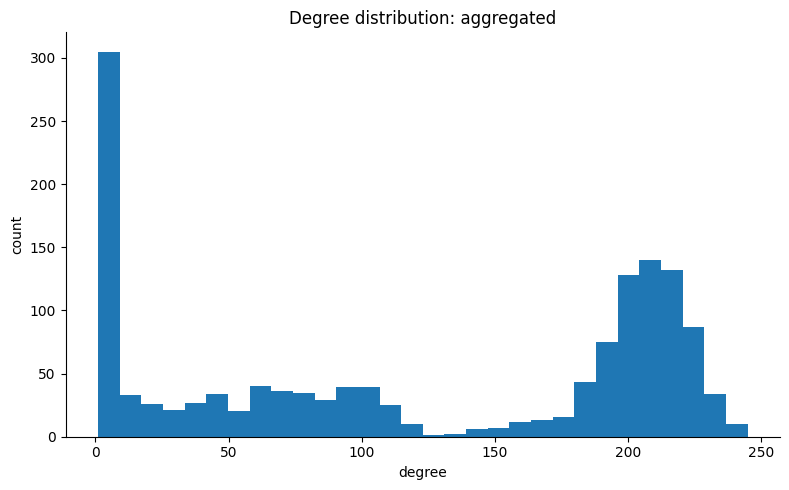

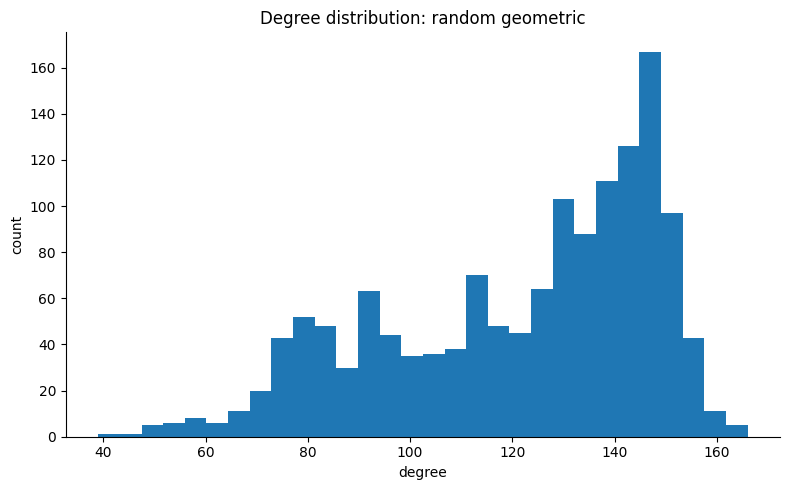

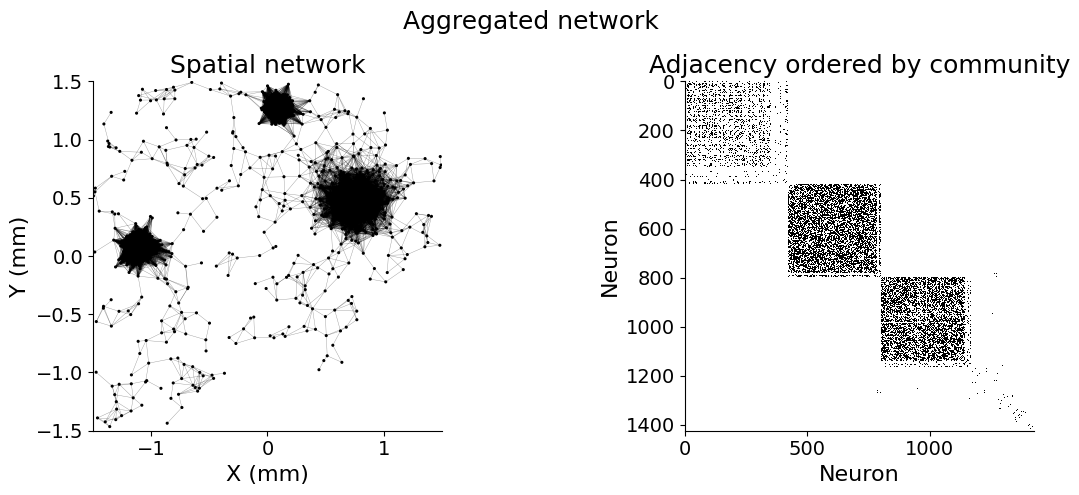

Number of nodes: 1425
Number of edges: 86583
Mean degree: 121.52
Density: 0.0853370786516854
Number of Louvain communities: 9
Community sizes: [420, 376, 369, 109, 63, 55, 14, 10, 9]


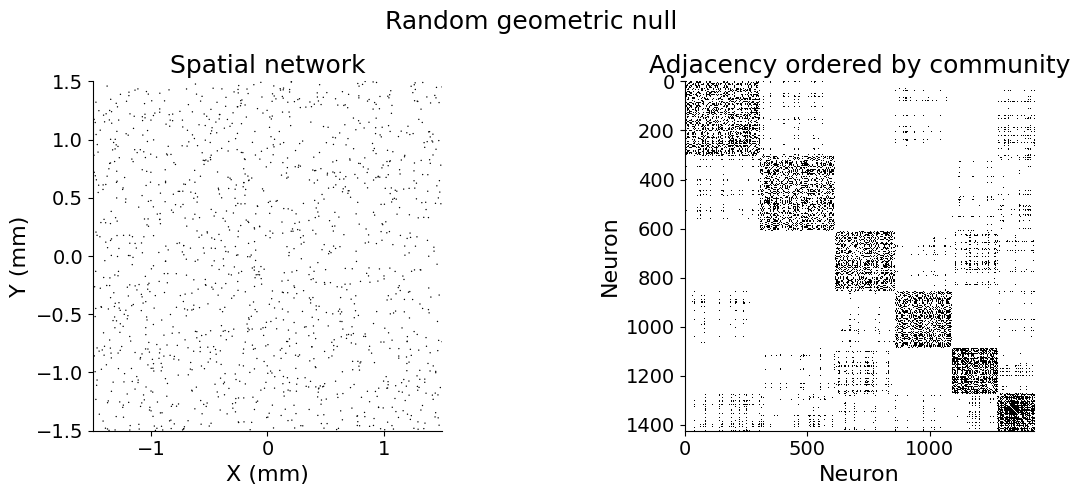

Number of nodes: 1425
Number of edges: 86583
Mean degree: 121.52
Density: 0.0853370786516854
Number of Louvain communities: 6
Community sizes: [307, 304, 246, 232, 185, 151]


In [63]:
def plot_network_and_adjacency(
    A,
    positions=None,
    title="Network",
    L=None,
    node_size=10,
    edge_alpha=0.4,
    draw_edges=False,
    show_community_lines=False,
    seed=0,
):
    """
    Plot spatial network, if positions are given, together with the
    adjacency matrix ordered by Louvain communities.

    Parameters
    ----------
    A : array, shape (N, N)
        Binary adjacency matrix.

    positions : array, shape (N, 2), optional
        Spatial positions of the nodes. positions[i] must correspond to A[i, :].

    title : str
        Main title.

    L : float, optional
        Spatial domain size. If given, axes are set to [-L/2, L/2].

    node_size : float
        Size of nodes in the spatial plot.

    edge_alpha : float
        Transparency of edges if draw_edges=True.

    draw_edges : bool
        If True, draw network edges on top of positions.
        For large networks, keep this False or the plot becomes too dense.

    show_community_lines : bool
        If True, draw red lines separating Louvain communities in the matrix.

    seed : int
        Random seed used by Louvain.
    """

    A = np.asarray(A)
    N = A.shape[0]

    assert A.shape[0] == A.shape[1], "A must be square."

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        communities = [set(range(N))]
    else:
        communities = nx.community.louvain_communities(G, seed=seed)
        communities = sorted(communities, key=len, reverse=True)

    ordered_nodes = []
    community_boundaries = []

    count = 0
    for comm in communities:
        comm_sorted = sorted(list(comm))
        ordered_nodes.extend(comm_sorted)
        count += len(comm_sorted)
        community_boundaries.append(count)

    A_ordered = A[np.ix_(ordered_nodes, ordered_nodes)]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        gridspec_kw={"width_ratios": [1, 1]}
    )

    # ============================================================
    # Left: spatial network
    # ============================================================

    ax = axes[0]

    if positions is not None:
        positions = np.asarray(positions)

        assert positions.shape[0] == N, (
            "positions must have the same number of rows as A has nodes."
        )
        assert positions.shape[1] == 2, (
            "positions must have shape (N, 2)."
        )

        if draw_edges:
            rows, cols = np.where(np.triu(A, k=1) > 0)

            for i, j in zip(rows, cols):
                ax.plot(
                    [positions[i, 0], positions[j, 0]],
                    [positions[i, 1], positions[j, 1]],
                    color="black",
                    alpha=edge_alpha,
                    linewidth=0.3,
                    zorder=1
                )

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            s=node_size,
            alpha=1,
            color="black",
            edgecolors="none",
            zorder=2
        )

        if L is not None:
            ax.set_xlim(-L / 2, L / 2)
            ax.set_ylim(-L / 2, L / 2)

        ax.set_aspect("equal")
        ax.set_xlabel("X (mm)", fontsize=16)
        ax.set_ylabel("Y (mm)", fontsize=16)
        ax.set_title("Spatial network", fontsize=18)
        ax.tick_params(labelsize=14)

    else:
        ax.text(
            0.5,
            0.5,
            "No positions passed",
            ha="center",
            va="center",
            fontsize=16
        )
        ax.set_axis_off()

    # ============================================================
    # Right: adjacency matrix ordered by communities
    # ============================================================

    ax = axes[1]

    ax.imshow(
        A_ordered,
        cmap="Greys",
        interpolation="nearest",
        origin="upper"
    )

    ax.set_title("Adjacency ordered by community", fontsize=18)
    ax.set_xlabel("Neuron", fontsize=16)
    ax.set_ylabel("Neuron", fontsize=16)
    ax.tick_params(labelsize=14)

    if show_community_lines:
        for boundary in community_boundaries[:-1]:
            ax.axhline(
                boundary - 0.5,
                color="red",
                linewidth=0.8,
                alpha=0.7
            )
            ax.axvline(
                boundary - 0.5,
                color="red",
                linewidth=0.8,
                alpha=0.7
            )

    fig.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

    print("Number of nodes:", N)
    print("Number of edges:", G.number_of_edges())
    print("Mean degree:", np.mean([d for _, d in G.degree()]))
    print("Density:", nx.density(G))
    print("Number of Louvain communities:", len(communities))
    print("Community sizes:", [len(c) for c in communities])

def plot_adjacency(A, title="Adjacency matrix", max_nodes=1000):
    """
    Plot adjacency matrix. For large networks, plot a subset to keep it readable.
    """
    A = clean_adjacency(A)
    n = A.shape[0]
    if n > max_nodes:
        idx = np.linspace(0, n - 1, max_nodes).astype(int)
        A_plot = A[np.ix_(idx, idx)]
        subtitle = f"showing {max_nodes} sampled nodes out of {n}"
    else:
        A_plot = A
        subtitle = f"n={n}"

    plt.figure(figsize=(6, 6))
    plt.imshow(A_plot, interpolation="nearest", aspect="equal")
    plt.title(f"{title}\n{subtitle}")
    plt.xlabel("node")
    plt.ylabel("node")
    plt.tight_layout()
    plt.show()


def plot_degree_distribution(A, label="network"):
    G = adjacency_to_graph(A, undirected=True)
    degrees = np.array([d for _, d in G.degree()])
    plt.figure()
    plt.hist(degrees, bins=30)
    plt.xlabel("degree")
    plt.ylabel("count")
    plt.title(f"Degree distribution: {label}")
    plt.tight_layout()
    plt.show()

    
plot_degree_distribution(A_agg, "aggregated")
plot_degree_distribution(A_rgg, "random geometric")
plot_network_and_adjacency(
    A=A_agg,
    positions=positions_agg,
    title="Aggregated network",
    L=3,
    node_size=5,
    draw_edges=True,
    show_community_lines=False,
    seed=SEED
)
plot_network_and_adjacency(
    A=A_rgg,
    positions=positions_rgg,
    title="Random geometric null",
    L=3,
    node_size=1,
    draw_edges=False,
    show_community_lines=False,
    seed=SEED
)

# 6. Structural metrics from the adjacency matrix

These metrics are computed after each damage step.

Most important:

- `giant_component_fraction`: how much of the network remains mutually connected.
- `mean_degree`: how many neighbours the surviving nodes still have.
- `global_efficiency_approx`: approximate communication efficiency.
- `average_clustering`: local triangle density.
- `n_components`: fragmentation.

For large networks, global efficiency is approximated by sampling source nodes. This is much faster and sufficient for comparing curves.

In [64]:
def approximate_global_efficiency(G, sample_size=200, seed=42):
    """
    Approximate global efficiency by sampling source nodes.

    Global efficiency is the average of 1 / shortest_path_length over pairs.
    Exact computation can be slow for large graphs, so we sample source nodes.
    """
    n = G.number_of_nodes()
    if n <= 1:
        return np.nan

    nodes = list(G.nodes())
    rng = np.random.default_rng(seed)

    if n <= sample_size:
        sources = nodes
    else:
        sources = list(rng.choice(nodes, size=sample_size, replace=False))

    total = 0.0
    count = 0

    for s in sources:
        lengths = nx.single_source_shortest_path_length(G, s)
        for t, d in lengths.items():
            if s != t and d > 0:
                total += 1.0 / d
                count += 1

    if count == 0:
        return 0.0

    # Scale is comparable across networks because the same sampling method is used.
    return total / count


def compute_structural_metrics(A, label=None, attack=None, fraction_removed=None, repeat=None, seed=42):
    """
    Compute structural metrics from an adjacency matrix.
    """
    A = symmetrise_adjacency(A)
    G = adjacency_to_graph(A, undirected=True)
    n = G.number_of_nodes()
    m = G.number_of_edges()

    row = {
        "network": label,
        "attack": attack,
        "fraction_removed": fraction_removed,
        "repeat": repeat,
        "n_nodes": n,
        "n_edges": m,
        "density": nx.density(G) if n > 1 else 0.0,
        "mean_degree": (2 * m / n) if n > 0 else np.nan,
        "average_clustering": nx.average_clustering(G) if n > 1 else np.nan,
    }

    if n == 0:
        row.update({
            "n_components": 0,
            "giant_component_size": 0,
            "giant_component_fraction": 0.0,
            "global_efficiency_approx": np.nan,
        })
        return row

    components = list(nx.connected_components(G))
    gc = max(components, key=len) if components else set()

    row.update({
        "n_components": len(components),
        "giant_component_size": len(gc),
        "giant_component_fraction": len(gc) / n if n > 0 else 0.0,
        "global_efficiency_approx": approximate_global_efficiency(
            G,
            sample_size=EFFICIENCY_SAMPLE_SIZE,
            seed=seed,
        ),
    })

    return row


baseline_structural = pd.DataFrame([
    compute_structural_metrics(A_agg, label="aggregated", attack="none", fraction_removed=0.0, repeat=0),
    compute_structural_metrics(A_rgg, label="random_geometric", attack="none", fraction_removed=0.0, repeat=0),
])
baseline_structural

,network,attack,fraction_removed,repeat,n_nodes,n_edges,density,mean_degree,average_clustering,n_components,giant_component_size,giant_component_fraction,global_efficiency_approx
0,aggregated,none,0.0,0,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,0.223181
1,random_geometric,none,0.0,0,1425,86583,0.085337,121.52,0.646122,1,1425,1.0,0.362993


# 7. Attack protocols

We use four damage protocols.

## 1. Random damage

Remove nodes uniformly at random. This tests generic robustness.

## 2. Degree attack / hub attack

Remove nodes with largest degree first. This tests whether the network depends on hubs.

## 3. Betweenness attack

Remove nodes with largest betweenness centrality first. This tests whether the network depends on shortest-path bridges.

In aggregated networks, this is usually the most interesting attack because bridge nodes between aggregates can have large betweenness even if they are not the highest-degree hubs.

## 4. Community-bridge attack

Detect communities and remove nodes with the largest number of inter-community links.

This is very interpretable for aggregated networks: it directly asks whether the network depends on neurons connecting different aggregates.

All orders are computed from the original undamaged network. This is a **static attack**. Adaptive attacks, where centrality is recomputed after every removal, are stronger but much slower.

In [69]:
def get_louvain_communities_safe(G, seed=42):
    """
    Compute communities using NetworkX Louvain if available.
    Fallback to greedy modularity communities otherwise.
    """
    try:
        return list(nx.community.louvain_communities(G, seed=seed))
    except Exception:
        return list(nx.community.greedy_modularity_communities(G))


def attack_order_degree(A):
    G = adjacency_to_graph(A, undirected=True)
    deg = dict(G.degree())
    return np.array(sorted(deg, key=deg.get, reverse=True), dtype=int)


def attack_order_betweenness(A, sample_size=200, seed=42):
    G = adjacency_to_graph(A, undirected=True)
    n = G.number_of_nodes()

    if n <= sample_size:
        btw = nx.betweenness_centrality(G, normalized=True)
    else:
        # Approximate betweenness using k sampled source nodes.
        btw = nx.betweenness_centrality(G, k=sample_size, normalized=True, seed=seed)

    return np.array(sorted(btw, key=btw.get, reverse=True), dtype=int)


def attack_order_community_bridge(A, seed=42):
    G = adjacency_to_graph(A, undirected=True)
    communities = get_louvain_communities_safe(G, seed=seed)

    node_to_comm = {}
    for c_id, comm in enumerate(communities):
        for node in comm:
            node_to_comm[node] = c_id

    bridge_score = defaultdict(int)
    for u, v in G.edges():
        if node_to_comm[u] != node_to_comm[v]:
            bridge_score[u] += 1
            bridge_score[v] += 1

    # Include all nodes, even if score is zero.
    for node in G.nodes():
        bridge_score[node] += 0

    return np.array(sorted(bridge_score, key=bridge_score.get, reverse=True), dtype=int)


def build_attack_orders(A, seed=42):
    """
    Build static targeted attack orders from the original network.
    """
    n = A.shape[0]
    return {
        "degree": attack_order_degree(A),
        "betweenness": attack_order_betweenness(A, sample_size=BETWEENNESS_SAMPLE_SIZE, seed=seed),
        "community_bridge": attack_order_community_bridge(A, seed=seed),
        # Random is generated separately for each repeat.
        "random": np.arange(n),
    }


def damage_adjacency(A, fraction_removed, attack="random", order=None, seed=42):
    """
    Remove a fraction of nodes and return the damaged compressed adjacency matrix.

    Parameters
    ----------
    A : ndarray
        Original adjacency matrix.
    fraction_removed : float
        Fraction of nodes to remove.
    attack : str
        'random', 'degree', 'betweenness', or 'community_bridge'.
    order : ndarray or None
        Static targeted attack order. Required for targeted attacks.
    seed : int
        Random seed for random damage.

    Returns
    -------
    A_damaged : ndarray
        Adjacency matrix induced by surviving nodes.
    survivors : ndarray
        Original node indices that survived.
    removed : ndarray
        Original node indices that were removed.
    """
    A = clean_adjacency(A)
    n = A.shape[0]
    k = int(np.round(fraction_removed * n))
    k = min(max(k, 0), n)

    if attack == "random":
        rng = np.random.default_rng(seed)
        removed = rng.choice(np.arange(n), size=k, replace=False)
    else:
        if order is None:
            raise ValueError("Targeted attacks require an attack order.")
        removed = np.asarray(order[:k], dtype=int)

    removed_set = set(removed.tolist())
    survivors = np.array([i for i in range(n) if i not in removed_set], dtype=int)
    A_damaged = A[np.ix_(survivors, survivors)]

    return A_damaged, survivors, removed


# Build orders once for each baseline network.
attack_orders = {
    "aggregated": build_attack_orders(A_agg, seed=SEED),
    "random_geometric": build_attack_orders(A_rgg, seed=SEED),
}

print("Attack orders computed.")
print("Available attacks:", list(attack_orders["aggregated"].keys()))
print('Available attacks for random geometric null:', list(attack_orders["random_geometric"].keys()))

Attack orders computed.
Available attacks: ['degree', 'betweenness', 'community_bridge', 'random']
Available attacks for random geometric null: ['degree', 'betweenness', 'community_bridge', 'random']


# 8. Visualize which nodes targeted attacks remove

This is useful for interpretation.

For the aggregated network, high-betweenness and community-bridge nodes should often sit between aggregates. Hubs may sit inside aggregates.

If this spatial distinction appears clearly, it gives you a very strong story:

> Hubs support local activity; bridge nodes support global integration.

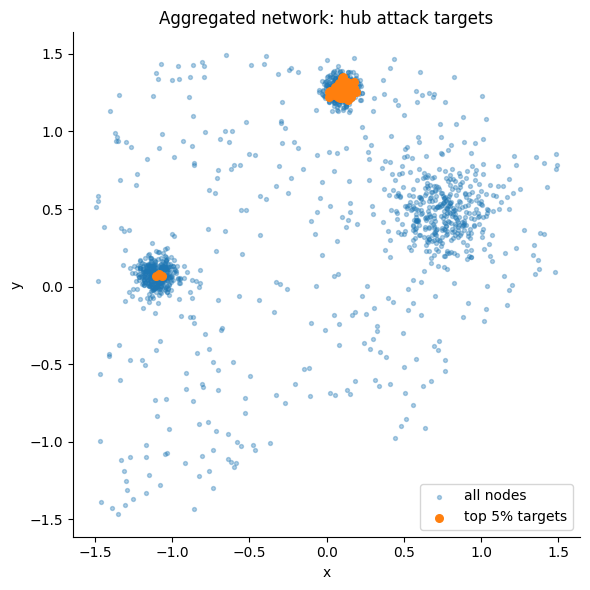

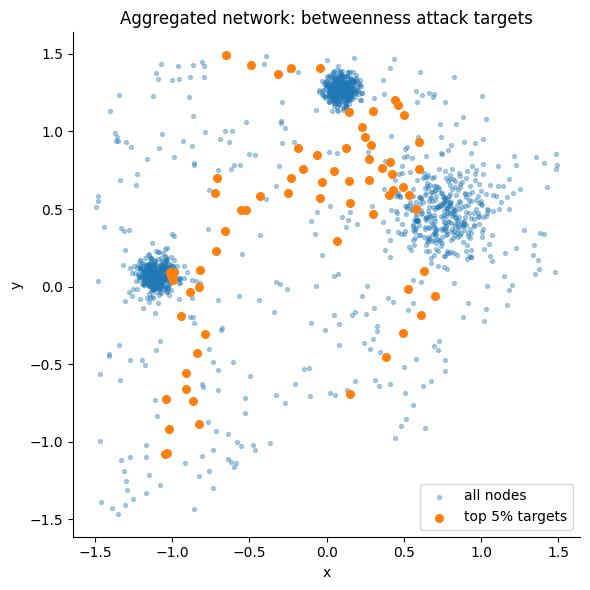

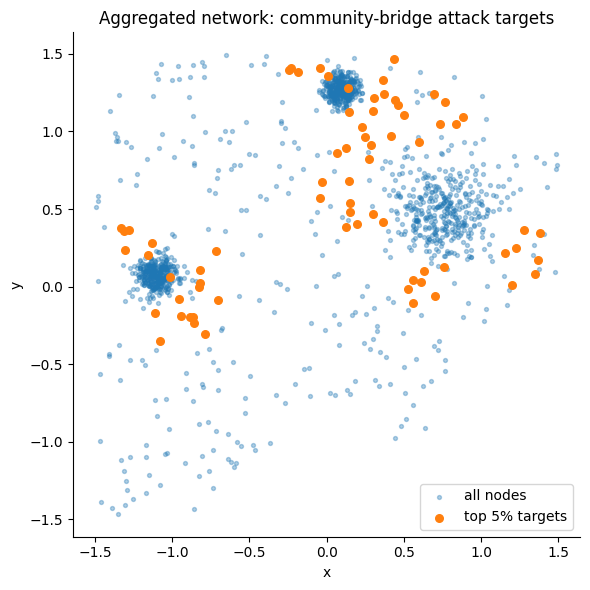

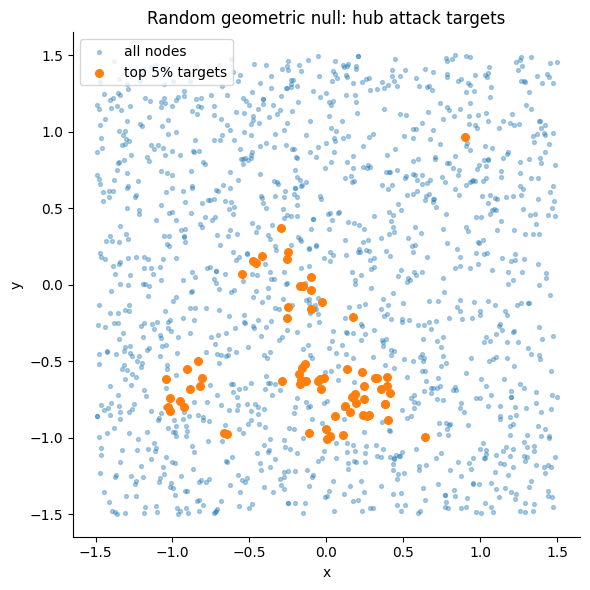

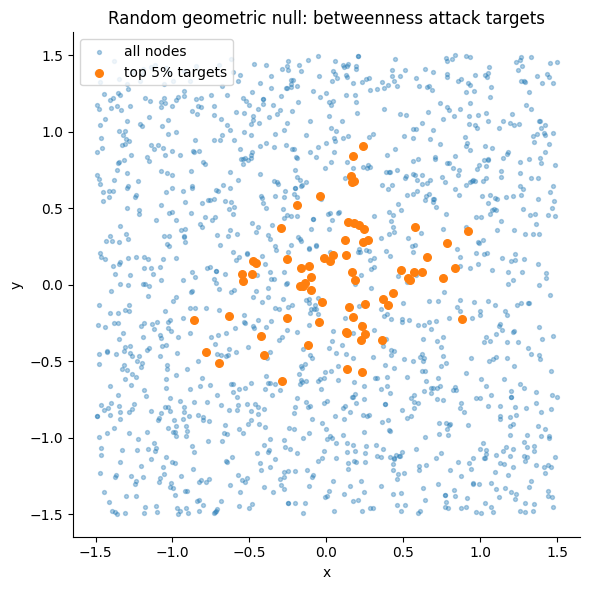

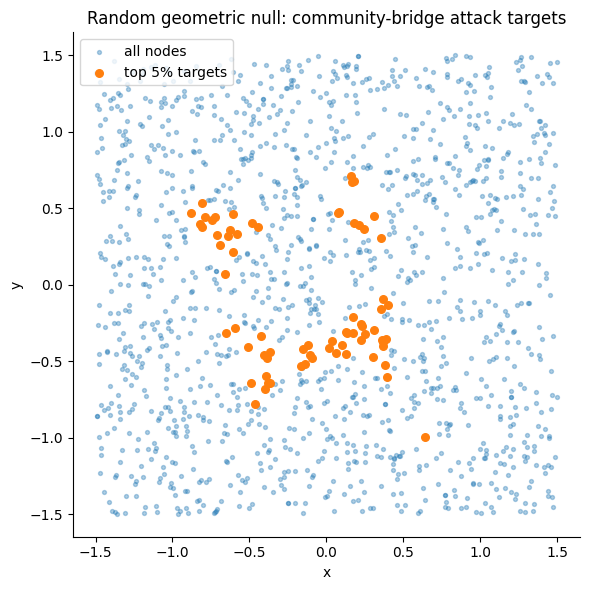

In [70]:
def plot_targeted_nodes(positions, order, title, top_fraction=0.05):
    """
    Plot top targeted nodes on the spatial map.
    Only works if positions are available.
    """
    if positions is None:
        print("No positions available for this network.")
        return

    n = len(positions)
    k = max(1, int(top_fraction * n))
    target = np.asarray(order[:k], dtype=int)

    plt.figure(figsize=(6, 6))
    plt.scatter(positions[:, 0], positions[:, 1], s=8, alpha=0.35, label="all nodes")
    plt.scatter(positions[target, 0], positions[target, 1], s=30, label=f"top {100*top_fraction:.0f}% targets")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()


# If this notebook generated positions_agg, we can show target locations.
# If you loaded A_agg from another notebook but did not pass positions, this cell will skip gracefully.
positions_for_plot = globals().get("positions_agg", None)

if positions_for_plot is not None:
    plot_targeted_nodes(positions_agg, attack_orders["aggregated"]["degree"], "Aggregated network: hub attack targets")
    plot_targeted_nodes(positions_agg, attack_orders["aggregated"]["betweenness"], "Aggregated network: betweenness attack targets")
    plot_targeted_nodes(positions_agg, attack_orders["aggregated"]["community_bridge"], "Aggregated network: community-bridge attack targets")
else:
    print("positions_agg was not found. Spatial target plots skipped.")

plot_targeted_nodes(positions_rgg, attack_orders["random_geometric"]["degree"], "Random geometric null: hub attack targets")
plot_targeted_nodes(positions_rgg, attack_orders["random_geometric"]["betweenness"], "Random geometric null: betweenness attack targets")
plot_targeted_nodes(positions_rgg, attack_orders["random_geometric"]["community_bridge"], "Random geometric null: community-bridge attack targets")

# 9. Izhikevich simulation from adjacency matrix

This section turns a damaged adjacency matrix into a spiking network.

Important design choice:

- We assign excitatory/inhibitory cell types **once at baseline**.
- After damage, surviving neurons keep their original type.

This avoids a major artefact: if we recomputed the first 80% as excitatory after every damage event, the E/I identity would depend on node ordering and damage fraction.

The simulation follows the same convention as your current notebook:

```python
I += np.sum(S[:, fired], axis=1)
```

That means column `j` of the synaptic matrix contains the outgoing effect of fired neuron `j` onto all postsynaptic neurons.

In [71]:
def assign_cell_types(N, excitatory_fraction=0.8, seed=42):
    """
    Randomly assign neuron types once.

    Returns an array of strings: 'E' for excitatory, 'I' for inhibitory.
    """
    rng = np.random.default_rng(seed)
    n_exc = int(round(excitatory_fraction * N))
    types = np.array(["E"] * n_exc + ["I"] * (N - n_exc))
    rng.shuffle(types)
    return types


def simulate_izhikevich_from_adjacency(
    A,
    cell_types=None,
    sim_time=1000,
    seed=42,
    max_exc_weight=10.0,
    max_inh_weight=0.5,
    noise_exc=3.0,
    noise_inh=2.0,
):
    """
    Simulate Izhikevich neurons on a given adjacency matrix.

    Parameters
    ----------
    A : ndarray
        Adjacency matrix among surviving neurons.
    cell_types : ndarray or None
        Array of 'E'/'I' labels for the surviving neurons.
        If None, labels are generated randomly.
    sim_time : int
        Simulation time in ms.

    Returns
    -------
    firings : ndarray, shape (n_spikes, 2)
        Each row is [time, neuron_index].
    """
    A = clean_adjacency(A)
    N = A.shape[0]

    if N == 0:
        return np.empty((0, 2), dtype=int)

    rng = np.random.default_rng(seed)

    if cell_types is None:
        Ne = int(0.8 * N)
        Ni = N - Ne

        cell_types = np.zeros(N, dtype=int)
        cell_types[:Ne] = 1      # excitatory
        cell_types[Ne:] = -1     # inhibitory
    else:
        cell_types = np.asarray(cell_types)

    exc_mask = (cell_types == 1)
    inh_mask = (cell_types == -1)

    Ne = exc_mask.sum()
    Ni = inh_mask.sum()

    # Izhikevich parameters.
    re = rng.random(N)
    ri = rng.random(N)

    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)
    d = np.zeros(N)

    # Excitatory regular-spiking-like neurons.
    a[exc_mask] = 0.02
    b[exc_mask] = 0.2
    c[exc_mask] = -65 + 15 * re[exc_mask] ** 2
    d[exc_mask] = 8 - 6 * re[exc_mask] ** 2

    # Inhibitory fast-spiking-like neurons.
    a[inh_mask] = 0.02 + 0.08 * ri[inh_mask]
    b[inh_mask] = 0.25 - 0.05 * ri[inh_mask]
    c[inh_mask] = -65
    d[inh_mask] = 2

    # Synaptic matrix S[post, pre].
    W = np.zeros((N, N))
    W[:, exc_mask] = max_exc_weight * rng.random((N, Ne)) if Ne > 0 else np.empty((N, 0))
    W[:, inh_mask] = -max_inh_weight * rng.random((N, Ni)) if Ni > 0 else np.empty((N, 0))
    S = A * W

    v = -65 * np.ones(N)
    u = b * v
    firings = []

    for t in range(1, sim_time + 1):
        I = np.zeros(N)
        I[exc_mask] = noise_exc * rng.normal(size=Ne)
        I[inh_mask] = noise_inh * rng.normal(size=Ni)

        fired = np.where(v >= 30)[0]

        if len(fired) > 0:
            firings.extend([(t, neuron) for neuron in fired])
            v[fired] = c[fired]
            u[fired] += d[fired]
            I += np.sum(S[:, fired], axis=1)

        # Two half-steps for numerical stability, as in the standard Izhikevich implementation.
        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        u += a * (b * v - u)

    return np.array(firings, dtype=int)


def compute_activity_metrics(firings, N, sim_time, bin_size=20):
    """
    Convert a raster into numerical activity metrics.
    """
    if N == 0 or sim_time <= 0:
        return {
            "n_spikes": 0,
            "mean_firing_rate_hz": np.nan,
            "active_fraction": 0.0,
            "population_rate_mean": np.nan,
            "population_rate_cv": np.nan,
        }

    if firings.size == 0:
        return {
            "n_spikes": 0,
            "mean_firing_rate_hz": 0.0,
            "active_fraction": 0.0,
            "population_rate_mean": 0.0,
            "population_rate_cv": 0.0,
        }

    n_spikes = len(firings)
    active_fraction = len(np.unique(firings[:, 1])) / N
    mean_firing_rate_hz = n_spikes / (N * sim_time / 1000.0)

    bins = np.arange(0, sim_time + bin_size, bin_size)
    counts, _ = np.histogram(firings[:, 0], bins=bins)
    pop_mean = counts.mean()
    pop_std = counts.std()
    pop_cv = pop_std / pop_mean if pop_mean > 0 else 0.0

    return {
        "n_spikes": n_spikes,
        "mean_firing_rate_hz": mean_firing_rate_hz,
        "active_fraction": active_fraction,
        "population_rate_mean": pop_mean,
        "population_rate_cv": pop_cv,
    }


def plot_raster(firings, title="Raster plot", max_spikes=100000):
    """
    Plot a raster. If there are too many spikes, plot a random subset.
    """
    if firings.size == 0:
        print("No spikes to plot.")
        return

    data = firings
    if len(data) > max_spikes:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(data), size=max_spikes, replace=False)
        data = data[idx]

    plt.figure(figsize=(10, 5))
    plt.scatter(data[:, 0], data[:, 1], s=3)
    plt.xlabel("time (ms)")
    plt.ylabel("neuron")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 10. Single damage demo

Before running the full experiment, inspect one damage case.

Good tests:

- `attack = "random"`, `fraction = 0.2`
- `attack = "degree"`, `fraction = 0.2`
- `attack = "betweenness"`, `fraction = 0.2`
- `attack = "community_bridge"`, `fraction = 0.2`

The raster is qualitative. The metrics are what you should use for final conclusions.

In [85]:
# Baseline cell types for the original aggregated network.
cell_types_agg = assign_cell_types(A_agg.shape[0], EXCITATORY_FRACTION, seed=SEED)
cell_types_rgg = assign_cell_types(A_rgg.shape[0], EXCITATORY_FRACTION, seed=SEED)

DEMO_NETWORK = "aggregated"          # 'aggregated' or 'random_geometric'
DEMO_ATTACK = "betweenness"          # 'random', 'degree', 'betweenness', 'community_bridge'
DEMO_FRACTION = 0.20

A0 = A_agg if DEMO_NETWORK == "aggregated" else A_rgg
cell_types0 = cell_types_agg if DEMO_NETWORK == "aggregated" else cell_types_rgg
order = None if DEMO_ATTACK == "random" else attack_orders[DEMO_NETWORK][DEMO_ATTACK]

A_demo, survivors_demo, removed_demo = damage_adjacency(
    A0,
    fraction_removed=DEMO_FRACTION,
    attack=DEMO_ATTACK,
    order=order,
    seed=SEED,
)

cell_types_demo = cell_types0[survivors_demo]

print("Structural metrics after demo damage:")
display(pd.DataFrame([compute_structural_metrics(
    A_demo,
    label=DEMO_NETWORK,
    attack=DEMO_ATTACK,
    fraction_removed=DEMO_FRACTION,
    repeat=0,
)]))

firings_demo = simulate_izhikevich_from_adjacency(
    A_demo,
    cell_types=cell_types_demo,
    sim_time=SIM_TIME,
    seed=SEED,
    max_exc_weight=MAX_EXC_WEIGHT,
    max_inh_weight=MAX_INH_WEIGHT,
    noise_exc=NOISE_EXC,
    noise_inh=NOISE_INH,
)

print("Activity metrics after demo damage:")
display(pd.DataFrame([compute_activity_metrics(
    firings_demo,
    N=A_demo.shape[0],
    sim_time=SIM_TIME,
    bin_size=BIN_SIZE,
)]))

plot_raster(
    firings_demo,
    title=f"{DEMO_NETWORK}, {DEMO_ATTACK} damage, f={DEMO_FRACTION}"
)

Structural metrics after demo damage:


,network,attack,fraction_removed,repeat,n_nodes,n_edges,density,mean_degree,average_clustering,n_components,giant_component_size,giant_component_fraction,global_efficiency_approx
0,aggregated,betweenness,0.2,0,1140,74169,0.114241,130.121053,0.484874,42,357,0.313158,0.697019


Activity metrics after demo damage:


,n_spikes,mean_firing_rate_hz,active_fraction,population_rate_mean,population_rate_cv
0,0,0.0,0.0,0.0,0.0


No spikes to plot.


# 11. Full damage experiment

This is the main loop.

For each network type:

- aggregated network,
- random geometric null,

and for each attack:

- random,
- degree,
- betweenness,
- community bridge,

we remove increasing fractions of nodes and compute structural and functional metrics.

For random damage, each repeat removes a different random set of nodes.

For targeted attacks, the node order is fixed, but the neural simulation still has stochastic noise. Therefore repeats are still useful.

In [81]:
def run_damage_experiment(
    networks,
    cell_types_by_network,
    attack_orders,
    damage_fractions,
    repeats=5,
    run_simulation=True,
    sim_time=1000,
    seed=42,
):
    """
    Run structural and optional functional damage analysis.
    """
    rows = []

    attacks = ["random", "degree", "betweenness", "community_bridge"]

    for network_name, A0 in networks.items():
        print(f"Running network: {network_name}")
        cell_types0 = cell_types_by_network[network_name]

        for attack in attacks:
            print(f"  attack: {attack}")
            order = None if attack == "random" else attack_orders[network_name][attack]

            for f in damage_fractions:
                for rep in range(repeats):
                    local_seed = seed + 10000 * rep + int(1000 * f) + hash((network_name, attack)) % 1000

                    A_dmg, survivors, removed = damage_adjacency(
                        A0,
                        fraction_removed=f,
                        attack=attack,
                        order=order,
                        seed=local_seed,
                    )

                    row = compute_structural_metrics(
                        A_dmg,
                        label=network_name,
                        attack=attack,
                        fraction_removed=f,
                        repeat=rep,
                        seed=local_seed,
                    )

                    if run_simulation:
                        surviving_types = cell_types0[survivors]
                        firings = simulate_izhikevich_from_adjacency(
                            A_dmg,
                            cell_types=surviving_types,
                            sim_time=sim_time,
                            seed=local_seed,
                            max_exc_weight=MAX_EXC_WEIGHT,
                            max_inh_weight=MAX_INH_WEIGHT,
                            noise_exc=NOISE_EXC,
                            noise_inh=NOISE_INH,
                        )
                        row.update(compute_activity_metrics(
                            firings,
                            N=A_dmg.shape[0],
                            sim_time=sim_time,
                            bin_size=BIN_SIZE,
                        ))

                    rows.append(row)

    return pd.DataFrame(rows)


networks = {
    "aggregated": A_agg,
    "random_geometric": A_rgg,
}

cell_types_by_network = {
    "aggregated": cell_types_agg,
    "random_geometric": cell_types_rgg,
}

# results = run_damage_experiment(
#     networks=networks,
#     cell_types_by_network=cell_types_by_network,
#     attack_orders=attack_orders,
#     damage_fractions=DAMAGE_FRACTIONS,
#     repeats=REPEATS,
#     run_simulation=RUN_SIMULATION,
#     sim_time=SIM_TIME,
#     seed=SEED,
# )

results.head(50)

,network,attack,fraction_removed,repeat,n_nodes,n_edges,density,mean_degree,average_clustering,n_components,giant_component_size,giant_component_fraction,global_efficiency_approx,n_spikes,mean_firing_rate_hz,active_fraction,population_rate_mean,population_rate_cv
0,aggregated,random,0.0,0,1425,86583,0.085337,121.520000,0.465189,1,1425,1.000000,0.217596,0,0.0,0.0,0.0,0.0
1,aggregated,random,0.0,1,1425,86583,0.085337,121.520000,0.465189,1,1425,1.000000,0.218394,0,0.0,0.0,0.0,0.0
2,aggregated,random,0.0,2,1425,86583,0.085337,121.520000,0.465189,1,1425,1.000000,0.212275,0,0.0,0.0,0.0,0.0
3,aggregated,random,0.0,3,1425,86583,0.085337,121.520000,0.465189,1,1425,1.000000,0.220252,0,0.0,0.0,0.0,0.0
4,aggregated,random,0.0,4,1425,86583,0.085337,121.520000,0.465189,1,1425,1.000000,0.223465,0,0.0,0.0,0.0,0.0
5,aggregated,random,0.1,0,1283,71018,0.086354,110.706157,0.466267,5,1268,0.988309,0.221574,0,0.0,0.0,0.0,0.0
6,aggregated,random,0.1,1,1283,70606,0.085853,110.063913,0.464773,9,1234,0.961808,0.228581,0,0.0,0.0,0.0,0.0
7,aggregated,random,0.1,2,1283,70800,0.086089,110.366329,0.467569,6,1261,0.982853,0.217881,0,0.0,0.0,0.0,0.0
8,aggregated,random,0.1,3,1283,70931,0.086248,110.570538,0.467845,8,851,0.663289,0.348737,0,0.0,0.0,0.0,0.0
9,aggregated,random,0.1,4,1283,70696,0.085963,110.204209,0.470494,11,826,0.643804,0.361459,0,0.0,0.0,0.0,0.0


# 12. Save results

Always save the raw result table. This lets you make plots later without rerunning the simulations.

In [74]:
OUT_DIR = Path("network_damage_results")
OUT_DIR.mkdir(exist_ok=True)

results_path = OUT_DIR / "damage_results.csv"
results.to_csv(results_path, index=False)
print(f"Saved results to: {results_path.resolve()}")

Saved results to: C:\Users\labor\Desktop\Neuroscience\Neuroscience-Damage-in-Aggregated-Networks\network_damage_results\damage_results.csv


# 13. Plot structural robustness curves

These are the most important structural plots.

Interpretation:

- A slow decrease in giant component fraction means robust connectivity.
- A sharp drop means fragmentation.
- If betweenness or community-bridge attack collapses earlier than random damage, the network depends on connector nodes.

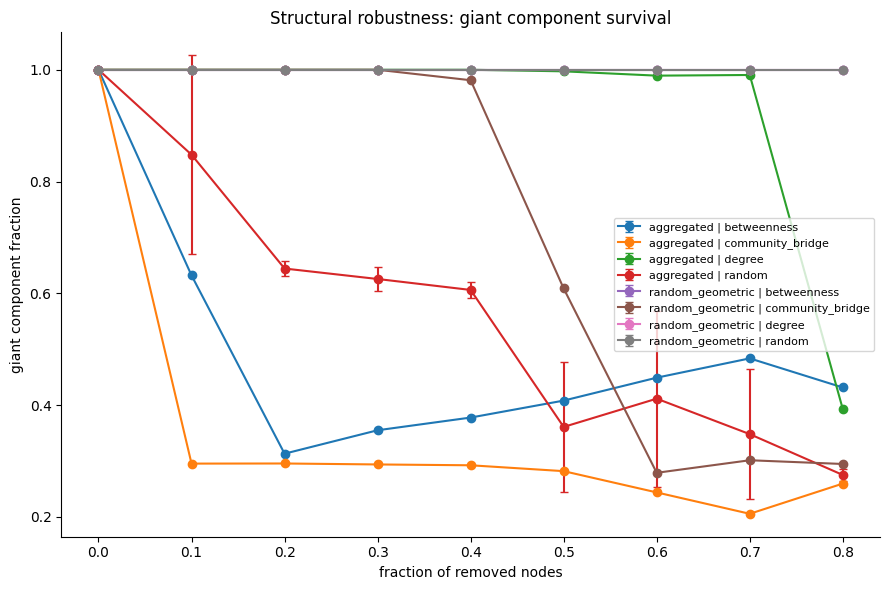

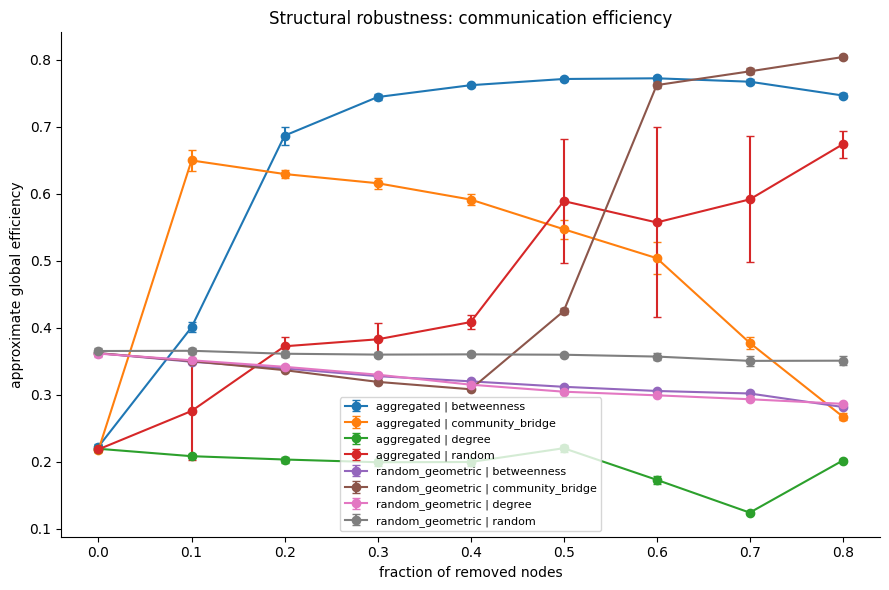

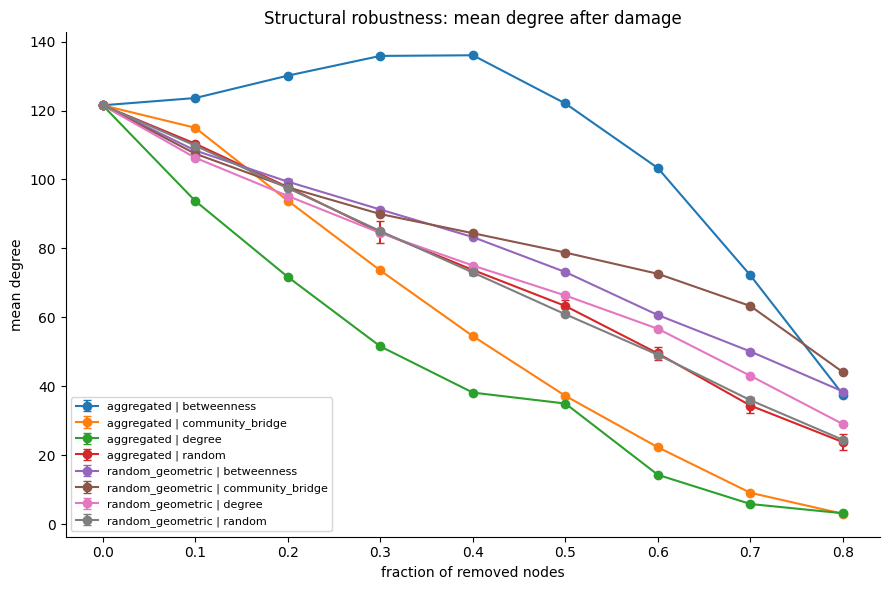

In [82]:
def summarize_results(df, metric):
    return (
        df.groupby(["network", "attack", "fraction_removed"], as_index=False)[metric]
        .agg(mean="mean", std="std", count="count")
    )


def plot_metric_curves(df, metric, ylabel=None, title=None):
    summary = summarize_results(df, metric)

    plt.figure(figsize=(9, 6))

    for (network, attack), sub in summary.groupby(["network", "attack"]):
        sub = sub.sort_values("fraction_removed")
        label = f"{network} | {attack}"
        yerr = sub["std"].fillna(0).to_numpy()
        plt.errorbar(
            sub["fraction_removed"],
            sub["mean"],
            yerr=yerr,
            marker="o",
            capsize=3,
            label=label,
        )

    plt.xlabel("fraction of removed nodes")
    plt.ylabel(ylabel if ylabel is not None else metric)
    plt.title(title if title is not None else metric)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_metric_curves(
    results,
    metric="giant_component_fraction",
    ylabel="giant component fraction",
    title="Structural robustness: giant component survival",
)

plot_metric_curves(
    results,
    metric="global_efficiency_approx",
    ylabel="approximate global efficiency",
    title="Structural robustness: communication efficiency",
)

plot_metric_curves(
    results,
    metric="mean_degree",
    ylabel="mean degree",
    title="Structural robustness: mean degree after damage",
)

# 14. Plot functional robustness curves

These plots connect structural damage to activity.

Most useful metrics:

- `mean_firing_rate_hz`: global activity level.
- `active_fraction`: fraction of surviving neurons that participate.
- `population_rate_cv`: burstiness / irregularity of population activity.

A network can remain structurally connected but functionally silent. That mismatch is scientifically interesting.

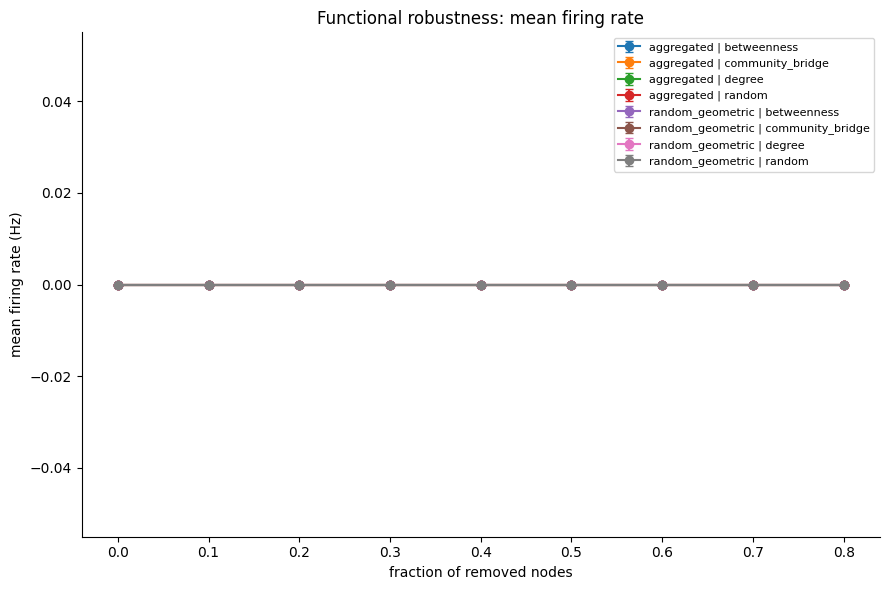

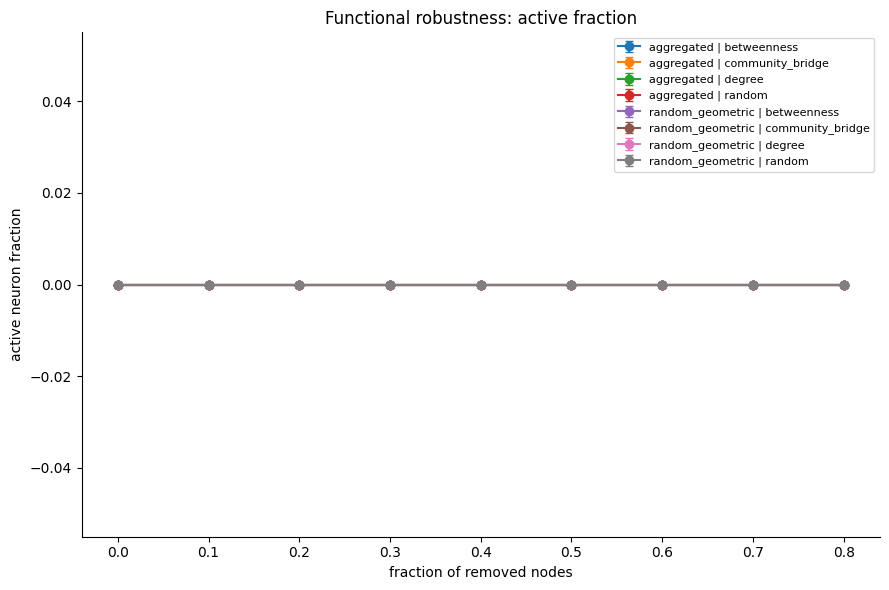

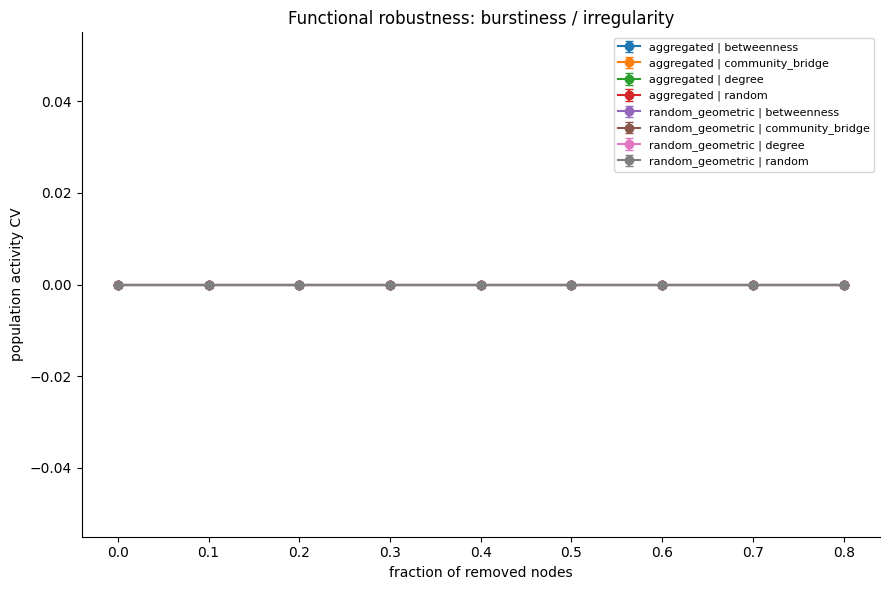

In [76]:
if RUN_SIMULATION:
    plot_metric_curves(
        results,
        metric="mean_firing_rate_hz",
        ylabel="mean firing rate (Hz)",
        title="Functional robustness: mean firing rate",
    )

    plot_metric_curves(
        results,
        metric="active_fraction",
        ylabel="active neuron fraction",
        title="Functional robustness: active fraction",
    )

    plot_metric_curves(
        results,
        metric="population_rate_cv",
        ylabel="population activity CV",
        title="Functional robustness: burstiness / irregularity",
    )
else:
    print("RUN_SIMULATION is False, so functional plots are skipped.")

# 15. Define functional survival / collapse

For final interpretation, it helps to classify each run.

A simple criterion:

- functional if mean firing rate remains above 20% of baseline and active fraction remains above 20%.
- silent if mean firing rate is very low.
- fragmented if only a small fraction of neurons are active.
- hyperactive if firing rate becomes much larger than baseline.

These thresholds are not universal. They are operational definitions. State them clearly in the project.

In [77]:
def add_functional_status(df):
    df = df.copy()

    if "mean_firing_rate_hz" not in df.columns:
        print("No functional metrics available.")
        return df

    baseline = (
        df[df["fraction_removed"] == 0]
        .groupby("network")["mean_firing_rate_hz"]
        .mean()
        .to_dict()
    )

    statuses = []
    for _, row in df.iterrows():
        base = baseline.get(row["network"], np.nan)
        mfr = row["mean_firing_rate_hz"]
        active = row["active_fraction"]

        if not np.isfinite(base) or base <= 0:
            statuses.append("undefined")
        elif mfr < 0.2 * base:
            statuses.append("silent")
        elif mfr > 2.0 * base:
            statuses.append("hyperactive")
        elif active < 0.2:
            statuses.append("fragmented")
        else:
            statuses.append("functional")

    df["functional_status"] = statuses
    return df


results_status = add_functional_status(results)

if "functional_status" in results_status.columns:
    display(
        results_status
        .groupby(["network", "attack", "fraction_removed", "functional_status"])
        .size()
        .reset_index(name="count")
        .head(60)
    )

,network,attack,fraction_removed,functional_status,count
0,aggregated,betweenness,0.0,undefined,5
1,aggregated,betweenness,0.1,undefined,5
2,aggregated,betweenness,0.2,undefined,5
3,aggregated,betweenness,0.3,undefined,5
4,aggregated,betweenness,0.4,undefined,5
5,aggregated,betweenness,0.5,undefined,5
6,aggregated,betweenness,0.6,undefined,5
7,aggregated,betweenness,0.7,undefined,5
8,aggregated,betweenness,0.8,undefined,5
9,aggregated,community_bridge,0.0,undefined,5


# 16. Representative rasters for final figures

Do not put dozens of rasters in the final report.

Use only a small number of representative cases, for example:

1. Baseline.
2. 20% random damage.
3. 20% hub attack.
4. 20% betweenness attack.
5. 20% community-bridge attack.

The curves are the result. The rasters are illustrations.

In [78]:
def simulate_and_plot_case(network_name, attack, fraction_removed, repeat_seed=0):
    A0 = networks[network_name]
    cell_types0 = cell_types_by_network[network_name]
    order = None if attack == "random" else attack_orders[network_name][attack]

    A_dmg, survivors, removed = damage_adjacency(
        A0,
        fraction_removed=fraction_removed,
        attack=attack,
        order=order,
        seed=SEED + repeat_seed,
    )

    firings = simulate_izhikevich_from_adjacency(
        A_dmg,
        cell_types=cell_types0[survivors],
        sim_time=SIM_TIME,
        seed=SEED + repeat_seed,
        max_exc_weight=MAX_EXC_WEIGHT,
        max_inh_weight=MAX_INH_WEIGHT,
        noise_exc=NOISE_EXC,
        noise_inh=NOISE_INH,
    )

    metrics = compute_activity_metrics(firings, A_dmg.shape[0], SIM_TIME, BIN_SIZE)
    print(network_name, attack, fraction_removed, metrics)
    plot_raster(firings, title=f"{network_name} | {attack} | f={fraction_removed}")


# Uncomment the cases you want to visualize.
#simulate_and_plot_case("aggregated", "random", 0.20)
#simulate_and_plot_case("aggregated", "degree", 0.2)
# simulate_and_plot_case("aggregated", "betweenness", 0.20)
# simulate_and_plot_case("aggregated", "community_bridge", 0.20)
# simulate_and_plot_case("random_geometric", "random", 0.20)
# simulate_and_plot_case("random_geometric", "betweenness", 0.20)

# 17. What results would be interesting?

Look for these patterns.

## Pattern A: Aggregated network robust to random damage

If the aggregated network keeps a large giant component and normal firing under random damage, this suggests local redundancy.

## Pattern B: Aggregated network fragile to betweenness or bridge attack

If betweenness or community-bridge damage collapses efficiency, active fraction or firing rate much earlier than random damage, this suggests global communication depends on a small connector set.

This would be the cleanest result.

## Pattern C: Random geometric null degrades more smoothly

If the random geometric graph does not show such a sharp targeted-attack collapse, then Gaussian aggregation is producing a special mesoscale vulnerability.

## Pattern D: Structural and functional collapse do not coincide

This is also interesting. For example:

- giant component survives but firing becomes silent,
- mean degree remains high but active fraction drops,
- structural fragmentation occurs before firing rate collapses.

That tells you that graph topology alone does not fully determine dynamics.

# 18. Recommended final figures

For the project report, I recommend:

1. **Baseline networks**: aggregated spatial network, random geometric network, adjacency matrices.
2. **Attack target maps**: top degree, betweenness, and bridge nodes on the aggregated network.
3. **Structural robustness curves**: giant component and global efficiency vs fraction removed.
4. **Functional robustness curves**: mean firing rate and active fraction vs fraction removed.
5. **Representative rasters**: baseline, random damage, hub attack, betweenness attack.

The key sentence you want to be able to defend is:

> Aggregation creates locally redundant modules, but makes global dynamics vulnerable to the targeted removal of connector nodes.